In [39]:
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import rlmod as rk
import scipy.linalg as la
import csv
import cmath as cm
import matplotlib as mpl
import matplotlib.pyplot as plt
from numpy import random

mpl.rcParams.update({'font.size': 12})
plt.rcParams['axes.axisbelow'] = True
%matplotlib widget
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.linewidth'] = 2
#mpl.rcParams['axes.prop_cycle'] = cycler(color='bgrkmyc')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["b", "g", "r", 'k','y' , 'm','tab:orange', 'tab:cyan', 'tab:brown', 'slategrey', 'deeppink' ]) 

In [40]:
bm = 200  # magnitud del pulso
nh = 5  # largo de la cadena
dt = 0.15   # intervalos de tiempo

# secuencias de acciones

action_sequence1 = np.asarray([14, 3, 1, 0, 3, 13, 6, 4, 0, 4, 13, 0, 0, 0, 14, 14, 3, 0,
                               0, 0, 14, 3, 0, 9, 14, 0, 14, 0, 0, 0, 0, 14, 14, 3, 0,
                               0, 0, 14, 3, 14, 14, 14, 9, 6, 14, 0, 6, 14, 14, 14, 14, 0, 5, 14, 14, 14, 5, 14,
                               0, 14, 14, 8, 8, 14, 14, 14, 0, 4, 0, 12, 14, 14, 14, 1, 0, 12,
                               14, 14, 3, 14, 14, 14, 14, 0, 14, 13, 10, 5, 14, 14, 5, 2, 14,
                               9, 9, 0, 14, 3, 1, 14, 9, 0, 5, 8, 5, 14, 0, 0, 14, 14, 0,
                               12, 14, 14, 0, 14, 9, 2, 0, 0, 14, 0, 0, 0, 14, 14, 3, 1, 14, 9,
                               14, 3, 0, 0, 0, 14, 3, 0, 0, 0, 14, 14, 0, 0, 14, 14, 0, 0, 14, 9, 14, 0, 0, 14, 9,
                               14, 0, 0, 5, 0, 0, 5, 3, 5, 0, 5, 8, 5, 9, 4, 0, 0, 5, 8, 5,
                               8, 14, 14, 14, 3, 14, 14, 14, 0, 0, 14, 12, 3, 14, 14, 14, 3,
                               14, 14, 0, 5, 8, 5, 14, 14, 14, 14, 3, 14, 14, 14, 3, 14, 14, 14, 14, 0,
                               0,  14]
                              )

action_sequence2 = np.asarray([14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 0, 0, 14, 14, 14, 14, 0, 13, 0, 0, 8, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 10, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
                               14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14]
                              )
action_sequence3 = np.asarray([0, 2, 1, 6, 4, 4, 5, 5, 11, 0, 2, 6, 10, 10, 10, 11, 0, 2, 5, 5, 5, 10, 10, 11,
                               15, 0, 2, 6, 10, 11, 15, 0, 2, 5, 11, 0, 2, 6, 9, 10, 9, 9, 11, 15, 0, 2, 6,
                               10, 9, 12, 0, 2, 5, 10, 8, 11, 0, 2, 6, 9, 8, 12, 15, 0, 2, 6, 10, 13, 14, 0, 0,
                               0, 2, 1, 1, 6, 8, 10, 11, 0, 2, 6, 10, 9, 7, 10, 13, 15, 0, 2, 6, 10, 11, 15, 0,
                               2, 6, 11, 15, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 6, 4, 6, 1, 1, 0, 2, 6, 1,
                               0, 2, 7, 8, 8, 1, 0, 2, 6, 5, 3, 4, 6, 1, 8, 1, 1, 0, 2, 6, 1, 1, 1, 1, 0, 0, 0, 2, 1,
                               2, 1, 1, 2, 6, 1, 1, 1, 0, 2, 6, 1, 0, 2, 6, 9, 1, 0, 2, 6, 9, 1, 1, 0, 0, 0, 2, 1, 1, 6, 4,
                               5, 4, 5, 5, 5, 1, 0, 2, 5, 4, 5, 5, 4, 4, 5, 5, 5, 1, 1, 1, 0, 0, 0, 2, 5, 4, 5, 6, 1, 9, 9])

action_sequence4 = np.asarray([6, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3,
                              3, 3, 3, 4, 4, 4, 7, 4, 3, 6, 3, 6, 2, 3, 6, 3, 6, 4, 6, 5, 4])

action_sequence5 = np.asarray(
    [8, 4, 4, 4, 5, 4, 4, 4, 5, 4, 4, 5, 6, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

action_sequence6 = np.asarray(
    [6, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])



In [41]:
# se generan las matrices de accion 
mat_acc = rk.acciones(bm, nh)
print(mat_acc[0])
comp_i = complex(0, 1)

# genero matrices para almacenar energías, bases y propagadores
en = np.zeros((16, nh), dtype=np.complex_)
bases = np.zeros((16, nh, nh), dtype=np.complex_)
propagadores = np.zeros((16, nh, nh), dtype=np.complex_)
desc_esp = np.zeros((16, nh, nh), dtype=np.complex_)

for j in range(0, 16): # para cada matriz de accion

            en[j, :], bases[j, :, :] = la.eig(mat_acc[j, :, :])

            for k in range(0, nh):
                p = np.outer(bases[j, :, k], bases[j, :,k])

                propagadores[j, :, :] = (
                    propagadores[j, :, :]
                    + cm.exp(-comp_i * dt * en[j, k]) * p
                )

                desc_esp[j,:,:] = desc_esp[j,:,:] + np.outer(bases[j, :, k], bases[j, :,k]) * en[j, k]


for k in np.arange(0,16):
        for i in np.arange(0,nh):
                for j in np.arange(0,nh):
            
                    if mat_acc[k,i,j]-desc_esp[k,i,j] > 1E-8:
                            print('error')


errores = np.matmul(propagadores[2,:,:],bases[2,:,2]) - np.exp(-comp_i*dt*en[2,2])*bases[2,:,2] 
et = np.sum(errores)
for a in np.arange(0,16):
       for j in np.arange(0,nh):
              errores = np.matmul(propagadores[a,:,:],bases[a,:,j]) - np.exp(-comp_i*dt*en[a,j])*bases[a,:,j] 
              et = np.sum(errores)




c0 = np.zeros(nh, dtype=np.complex_)
e0, base0 = rk.gen_base(nh)
c0[0] = 1.
t = 0

[[ 0.         -1.          0.          0.          0.        ]
 [-1.          0.         -1.22474487  0.          0.        ]
 [ 0.         -1.22474487  0.         -1.22474487  0.        ]
 [ 0.          0.         -1.22474487  0.         -1.        ]
 [ 0.          0.          0.         -1.          0.        ]]


In [42]:
state = c0
fid_evolution = []

ev_real_n = [np.real(state[nh-1])**2]
ev_imag_n = [np.imag(state[nh-1])**2]
ev_real_0 = [np.real(state[0])**2]
ev_imag_0 = [np.imag(state[0])**2]
ev_norm = [la.norm(state)]

action_sequence = action_sequence2

for action in action_sequence:
    
    state = np.matmul(propagadores[action, :, :], state)
    fid = np.real(state[nh-1]*np.conjugate(state[nh-1]))
    
    #fid = np.real(state[nh-1])**2+np.imag(state[nh-1])**2
    fid_evolution = np.append(fid_evolution,fid)
    
    ev_real_n = np.append(ev_real_n,np.real(state[nh-1])**2)
    ev_imag_n = np.append(ev_imag_n,np.imag(state[nh-1])**2)
    ev_real_0 = np.append(ev_real_0,np.real(state[0])**2)
    ev_imag_0 = np.append(ev_imag_0,np.imag(state[0])**2)
    ev_norm = np.append(ev_norm,la.norm(state))
    

    if abs(la.norm(state) - 1.)>1E8:
        print('FALLO EN LA NORMALIZACION',la.norm(state))

    #else:
        #print('NORMALIZACION OK: ',la.norm(state))


In [43]:
max_fid = 0.
while max_fid < 0.95:    
    state = c0
    fid_evolution = []

    ev_real_n = [np.real(state[nh-1])**2]
    ev_imag_n = [np.imag(state[nh-1])**2]
    ev_real_0 = [np.real(state[0])**2]
    ev_imag_0 = [np.imag(state[0])**2]
    ev_norm = [la.norm(state)]
    action_sequence7 = np.random.randint(0,16,size=200)
    action_sequence = action_sequence7
    for action in action_sequence:
        
        state = np.matmul(propagadores[action, :, :], state)
        fid = np.real(state[nh-1]*np.conjugate(state[nh-1]))
        #fid = np.real(state[nh-1])**2+np.imag(state[nh-1])**2
        fid_evolution = np.append(fid_evolution,fid)
        
        ev_real_n = np.append(ev_real_n,np.real(state[nh-1])**2)
        ev_imag_n = np.append(ev_imag_n,np.imag(state[nh-1])**2)
        ev_real_0 = np.append(ev_real_0,np.real(state[0])**2)
        ev_imag_0 = np.append(ev_imag_0,np.imag(state[0])**2)
        ev_norm = np.append(ev_norm,la.norm(state))
        

        if abs(la.norm(state) - 1.)>1E8:
            print('FALLO EN LA NORMALIZACION',la.norm(state))

        #else:
            #print('NORMALIZACION OK: ',la.norm(state))

    tsteps = np.shape(action_sequence)[0]
    max_fid = np.max(fid_evolution)
    max_action = np.argmax(fid_evolution)
    print(max_fid)
axs = plt.figure(figsize=(11,5))
plt.plot(np.arange(0,tsteps,1),fid_evolution, '-o')
plt.grid()
plt.axhline(y = 0.95, color = 'black', linestyle = '--')
plt.text(tsteps*0.8,0.9,'f = 0.95')
plt.title(' RED 6 (IGA y IRS) , max. fid = {}, accion # {}'.format(max_fid,max_action))
plt.xlabel('t/dt')
plt.ylabel('Fidelidad')

0.5243514322712189


0.689933403837884
0.624009022430812
0.2705157537341358
0.5560465942882324
0.48068205803860786
0.43017886502180563
0.3897140299154416
0.7477097760000173
0.49138137792278536
0.5055085718138385
0.3251825285509639
0.5309698362712388
0.3588813994868093
0.4420912496631284
0.26671953990235897
0.6102355863080221
0.28304977056148234
0.33814210022837915
0.6363659945838684
0.36898006130951194
0.5850734989379709
0.1708313868416471
0.25460515563184305
0.5004551609447297
0.38792748436761965
0.6352923462029392
0.25169874399293757
0.1588596900269113
0.8273409487323324
0.4469224704013094
0.5537021460584841
0.29909165104130137
0.5184851225251914
0.546619688200969
0.4089497264215171
0.6659686548522962
0.8078871002466789
0.6471837055837373
0.46406797534291744
0.7162228989759333
0.27743512596099823
0.24354727504503823
0.4403644010351382
0.4253350622450798
0.5431995679644832
0.5309801150812362
0.37925472458245996
0.7156245093037554
0.787608052805646
0.3674759495222134
0.2721324243357023
0.49905151748455345


KeyboardInterrupt: 

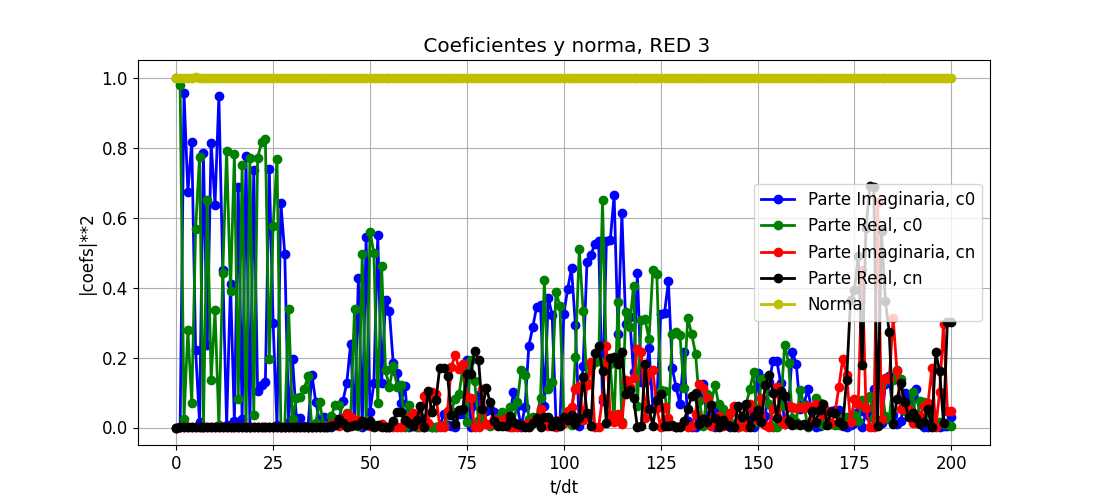

In [ ]:
axs = plt.figure(figsize=(11,5))
tsteps = np.shape(action_sequence)[0] + 1
max_fid = np.max(fid_evolution)
max_action = np.argmax(fid_evolution)

plt.plot(np.arange(0,tsteps,1),ev_imag_0, '-o', label = 'Parte Imaginaria, c0')
plt.plot(np.arange(0,tsteps,1),ev_real_0, '-o', label = 'Parte Real, c0')
plt.plot(np.arange(0,tsteps,1),ev_imag_n, '-o', label = 'Parte Imaginaria, cn')
plt.plot(np.arange(0,tsteps,1),ev_real_n, '-o', label = 'Parte Real, cn')
plt.plot(np.arange(0,tsteps,1),ev_norm, '-o', label = 'Norma')
plt.grid()
plt.title(' Coeficientes y norma, RED 3'.format(max_fid,max_action))
plt.xlabel('t/dt')
plt.ylabel('|coefs|**2')
plt.legend()